In [18]:
import pandas as pd
import os
import re
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import scipy.stats as stats

In [19]:
# ICD chapter ranges
icd_chapters = {
    "A00-B99": "Infectious diseases",
    "C00-D49": "Neoplasms",
    "D50-D89": "Blood and immune disorders",
    "E00-E89": "Metabolic diseases",
    "F01-F99": "Mental disorders",
    "G00-G99": "Nervous system diseases",
    "H00-H59": "Eye diseases",
    "H60-H95": "Ear diseases",
    "I00-I99": "Circulatory diseases",
    "J00-J99": "Respiratory diseases",
    "K00-K95": "Digestive diseases",
    "L00-L99": "Skin diseases",
    "M00-M99": "Musculoskeletal diseases",
    "N00-N99": "Genitourinary diseases",
    "O00-O99": "Pregnancy and childbirth",
    # "P00-P96": "Perinatal period conditions",
    "Q00-Q99": "Congenital disorder",
    "R00-R99": "Symptoms and abnormal findings",
    "S00-T88": "Injury and external causes",
    "V00-Y99": "External causes of morbidity",
    # "Z00-Z99": "Health factors",
    # "U00-U85": "Special purposes",
}
# Roman numerals aligned with the 22 official ICD-10 chapter numbers (I .. XXII)
roman_numerals = [
    "I",   "II",   "III",  "IV",  "V",
    "VI",  "VII",  "VIII", "IX",  "X",
    "XI",  "XII",  "XIII", "XIV", "XV",
    # "XVI", 
    "XVII", "XVIII","XIX", "XX",
    # "XXI", "XXII",
]
chapter2roman_map = {v: r for v, r in zip(icd_chapters.values(), roman_numerals)}
roman2chapter_map = {v: k for k, v in chapter2roman_map.items()}

# color palette
colors = sns.color_palette("tab20", len(roman_numerals))
roman2color_map = dict(zip(roman_numerals, colors))
chapter2color_map = dict(zip(icd_chapters.values(), colors))

### map icd to icd chapters ###

def parse_code(code):
    m = re.match(r"([A-Z]+)(\d+)", str(code))
    if not m:
        return None, None
    letter, number = m.groups()
    number = number[:2]
    return letter, int(number)

def in_range(code, start, end):
    start_l, start_n = parse_code(start)
    end_l, end_n = parse_code(end)
    code_l, code_n = parse_code(code)
    if start_l > code_l:
        return False
    if end_l < code_l:
        return False
    else:
        if start_l < code_l < end_l:
            return True
        if start_l == code_l and end_l == code_l and code_n >= start_n and code_n <= end_n:
            return True
        if start_l == code_l and end_l != code_l and code_n >= start_n:
            return True
        if start_l < code_l and end_l == code_l and code_n <= end_n:
            return True
    return False

def assign_chapter(icd_code):
    for rng, name in icd_chapters.items():
        start, end = rng.split("-")
        if in_range(icd_code, start, end):
            return name
    return "Unknown"

### Construct pmatrix and bmatrix

In [20]:
# get data
temp = pd.read_csv(os.path.join("../results", "ensemble_prs", "aou_ensembleprs_overall_reporttraits.csv"))
target_trait_list = sorted(temp["icd"].tolist())
n_target_traits = len(target_trait_list)

temp = pd.read_csv(os.path.join("../results", "ensemble_prs", "aou_ensembleprs_overall_alltraits.csv"))
candidate_trait_list = sorted(temp["icd"].tolist())
n_candidate_traits = len(candidate_trait_list)

# generate map between phenocode and icd
pheno2icd = pd.read_csv(os.path.join("../reference_data", "european_icd_phenocode_pairs.csv"))

### Construct P-matrix in AoU from pre-generated Top10 selection file ###

top10_df = pd.read_csv(os.path.join("../results", "candidate_selection", "aou_european_top10_cross_trait_selection.csv"))

# Initialize P-matrix
pmatrix = np.zeros((n_target_traits, n_candidate_traits))

# ICD -> matrix index
cicd_to_idx = {icd: idx for idx, icd in enumerate(candidate_trait_list)}
ticd_to_idx = {icd: idx for idx, icd in enumerate(target_trait_list)}

# Fill P-matrix using rank weights:
for _, row in top10_df.iterrows():
    target_icd = row["target_icd"]
    candidate_icd = row["prs_icd"]
    rank = row["rank"]

    if target_icd not in ticd_to_idx:
        continue

    if candidate_icd not in cicd_to_idx:
        continue

    i = ticd_to_idx[target_icd]
    j = cicd_to_idx[candidate_icd]

    pmatrix[i, j] = 11 - rank

# Convert to DataFrame
aou_pmatrix = pd.DataFrame(pmatrix, index=target_trait_list, columns=candidate_trait_list)

In [5]:
top10_df = pd.read_csv(os.path.join("../results", "candidate_selection", "ukb_european_top10_cross_trait_selection.csv"))

# Initialize P-matrix
pmatrix = np.zeros((n_target_traits, n_candidate_traits))

# Fill P-matrix using rank weights:
for _, row in top10_df.iterrows():
    target_icd = row["target_icd"]
    candidate_icd = row["prs_icd"]
    rank = row["rank"]

    if target_icd not in ticd_to_idx:
        continue

    if candidate_icd not in cicd_to_idx:
        continue

    i = ticd_to_idx[target_icd]
    j = cicd_to_idx[candidate_icd]

    pmatrix[i, j] = 11 - rank

# Convert to DataFrame
ukb_pmatrix = pd.DataFrame(pmatrix, index=target_trait_list, columns=candidate_trait_list)

In [6]:
aou_bmatrix = (aou_pmatrix > 0).astype(int)
ukb_bmatrix = (ukb_pmatrix > 0).astype(int)

In [7]:
# Sort row and columns by ICD code
roman_to_idx = {roman: idx for idx, roman in enumerate(roman_numerals)}

# aou_pmatrix
row_meta = pd.DataFrame({"icd": aou_pmatrix.index})
row_meta["chapter"] = row_meta["icd"].apply(assign_chapter)
row_meta["roman"] = row_meta["chapter"].map(chapter2roman_map)
row_meta["roman_index"] = row_meta["roman"].map(roman_to_idx)

col_meta = pd.DataFrame({"icd": aou_pmatrix.columns})
col_meta["chapter"] = col_meta["icd"].apply(assign_chapter)
col_meta["roman"] = col_meta["chapter"].map(chapter2roman_map)
col_meta["roman_index"] = col_meta["roman"].map(roman_to_idx)

row_meta = row_meta.sort_values(["roman_index", "icd"], ascending=[True, True]).reset_index(drop=True)
col_meta = col_meta.sort_values(["roman_index", "icd"], ascending=[True, True]).reset_index(drop=True)

aou_pmatrix = aou_pmatrix.loc[row_meta["icd"], col_meta["icd"]]

# ukb_pmatrix
row_meta = pd.DataFrame({"icd": ukb_pmatrix.index})
row_meta["chapter"] = row_meta["icd"].apply(assign_chapter)
row_meta["roman"] = row_meta["chapter"].map(chapter2roman_map)
row_meta["roman_index"] = row_meta["roman"].map(roman_to_idx)

col_meta = pd.DataFrame({"icd": ukb_pmatrix.columns})
col_meta["chapter"] = col_meta["icd"].apply(assign_chapter)
col_meta["roman"] = col_meta["chapter"].map(chapter2roman_map)
col_meta["roman_index"] = col_meta["roman"].map(roman_to_idx)

row_meta = row_meta.sort_values(["roman_index", "icd"], ascending=[True, True]).reset_index(drop=True)
col_meta = col_meta.sort_values(["roman_index", "icd"], ascending=[True, True]).reset_index(drop=True)

ukb_pmatrix = ukb_pmatrix.loc[row_meta["icd"], col_meta["icd"]]

### Fig2a. Heatmap

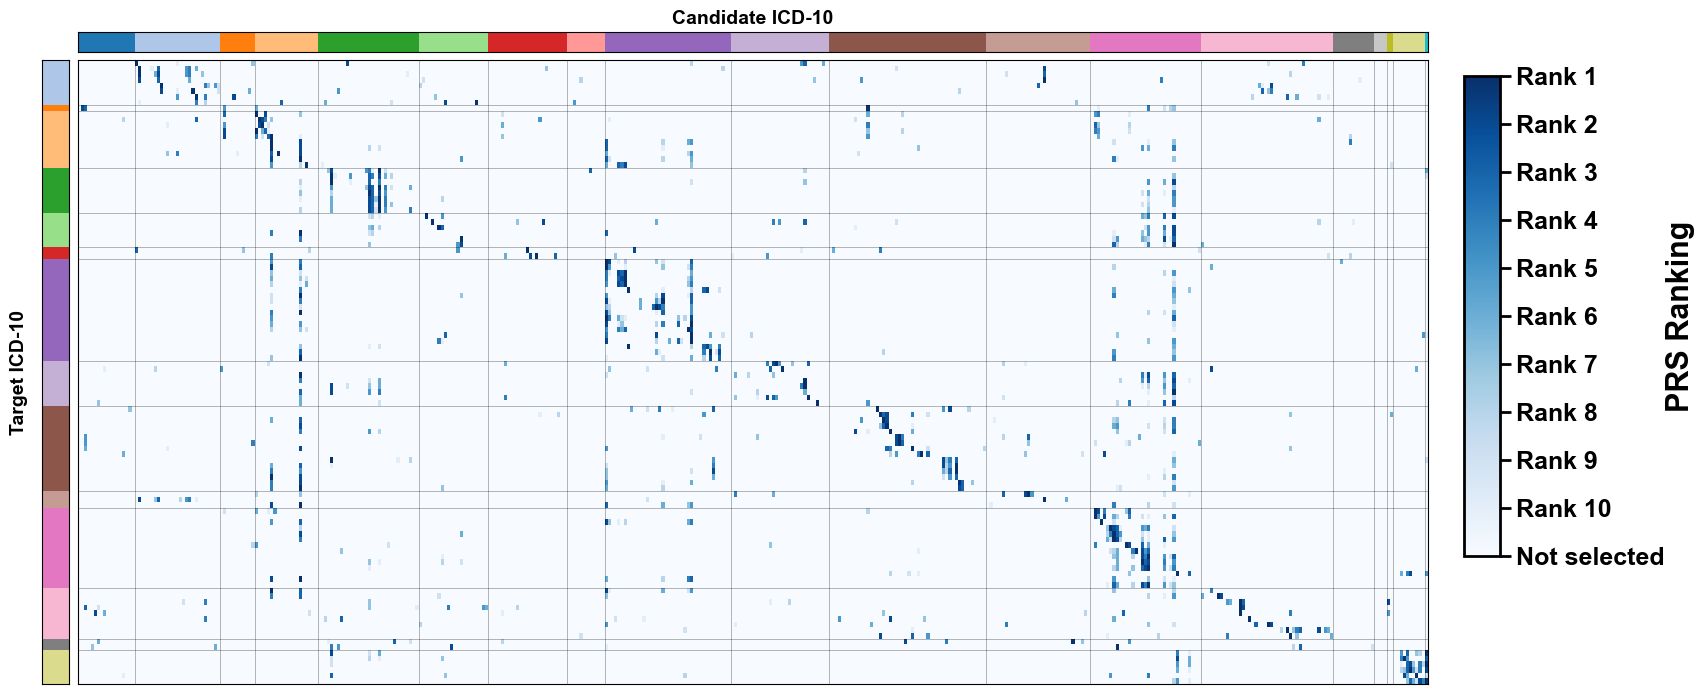

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import matplotlib
import seaborn as sns

matplotlib.rcParams["font.family"] = "Arial"

row_icd = list(aou_pmatrix.index)
col_icd = list(aou_pmatrix.columns)

row_chapters = [assign_chapter(icd) for icd in row_icd]
col_chapters = [assign_chapter(icd) for icd in col_icd]

row_colors = [chapter2color_map.get(ch) for ch in row_chapters]
col_colors = [chapter2color_map.get(ch) for ch in col_chapters]

# -----------------------------
# Figure layout
# -----------------------------
fig = plt.figure(figsize=(18, 8))

ax_colstrip = fig.add_axes([0.09, 0.91, 0.75, 0.025])
ax_rowstrip = fig.add_axes([0.07, 0.12, 0.015, 0.78])
ax_hm       = fig.add_axes([0.09, 0.12, 0.75, 0.78])
ax_cbar     = fig.add_axes([0.86, 0.28, 0.02, 0.60])

# -----------------------------
# Row chapter color strip
# -----------------------------
row_strip_array = np.array([mcolors.to_rgba(c) for c in row_colors]).reshape(len(row_icd), 1, 4)
ax_rowstrip.imshow(row_strip_array, aspect="auto", origin="upper")

ax_rowstrip.set_xticks([])
ax_rowstrip.set_yticks([])
ax_rowstrip.set_ylabel("Target ICD-10", fontsize=14, fontweight="bold", labelpad=10)

# -----------------------------
# Column chapter color strip
# -----------------------------
col_strip_array = np.array([mcolors.to_rgba(c) for c in col_colors]).reshape(1, len(col_icd), 4)
ax_colstrip.imshow(col_strip_array, aspect="auto", origin="upper")

ax_colstrip.set_xticks([])
ax_colstrip.set_yticks([])
ax_colstrip.set_title("Candidate ICD-10", fontsize=14, fontweight="bold", pad=6)

# -----------------------------
# Heatmap
# -----------------------------
sns.heatmap(
    aou_pmatrix,
    cmap="Blues",
    vmin=0,
    vmax=10,
    ax=ax_hm,
    xticklabels=False,
    yticklabels=False,
    cbar=False
)

ax_hm.set_xlabel("")
ax_hm.set_ylabel("")

for _, spine in ax_hm.spines.items():
    spine.set_visible(True)
    spine.set_linewidth(0.8)

# -----------------------------
# Chapter boundaries
# -----------------------------
row_boundaries = [i for i in range(1, len(row_chapters)) if row_chapters[i] != row_chapters[i - 1]]
col_boundaries = [i for i in range(1, len(col_chapters)) if col_chapters[i] != col_chapters[i - 1]]

for b in row_boundaries:
    ax_hm.axhline(b, color="black", linewidth=0.4, alpha=0.5)

for b in col_boundaries:
    ax_hm.axvline(b, color="black", linewidth=0.4, alpha=0.5)

# -----------------------------
# Colorbar
# -----------------------------
sm = plt.cm.ScalarMappable(cmap="Blues", norm=plt.Normalize(vmin=0, vmax=10))
sm.set_array([])

cbar = fig.colorbar(sm, cax=ax_cbar,ticks=list(range(11)))
cbar.set_ticklabels(["Not selected"] + [f"Rank {11 - v}" for v in range(1, 11)])
cbar.set_label("PRS Ranking", fontsize=22, fontweight="bold", labelpad=1)
cbar.outline.set_linewidth(2)
cbar.ax.tick_params(width=2, length=8)

for spine in cbar.ax.spines.values():
    spine.set_linewidth(2)
for label in cbar.ax.get_yticklabels():
    label.set_fontweight("bold")
    label.set_fontsize(18)

plt.show()

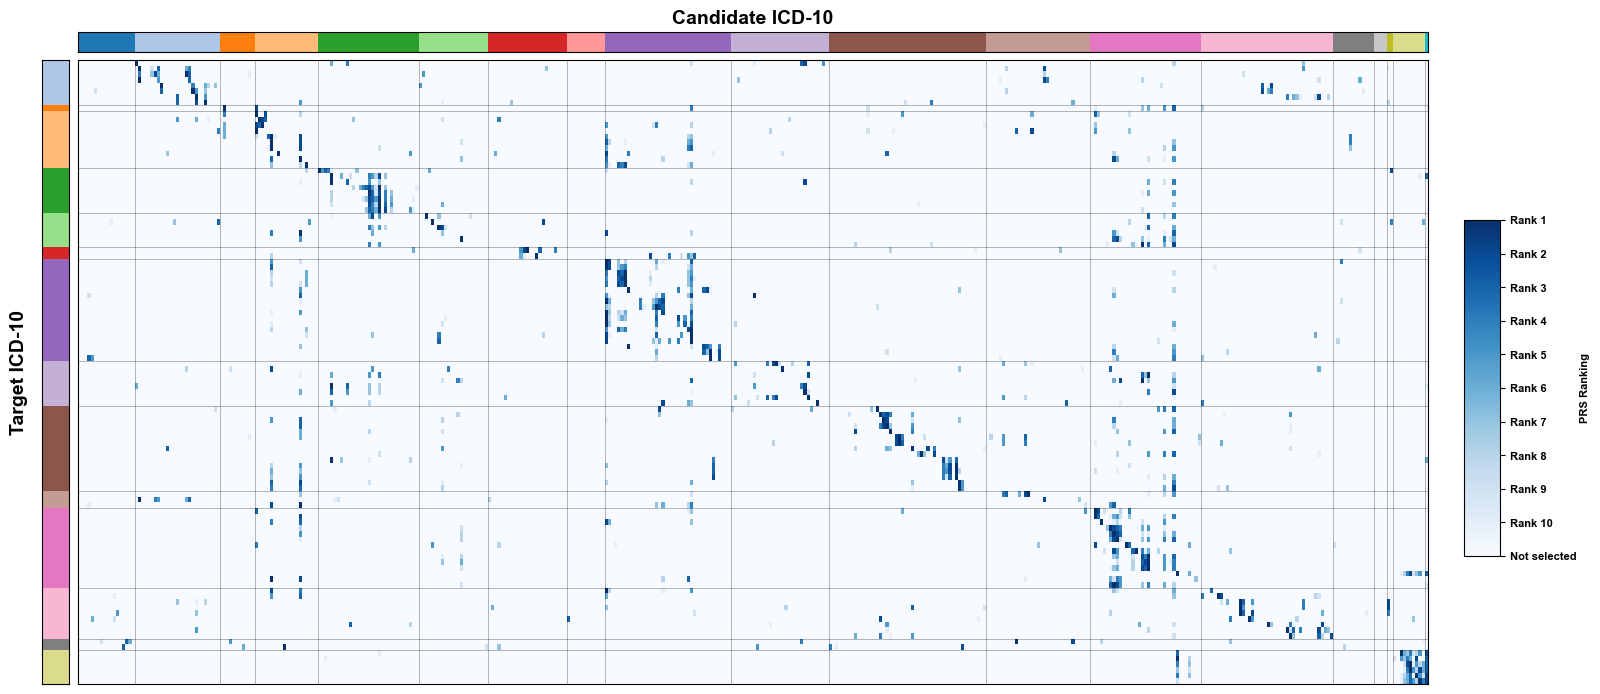

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import matplotlib
import seaborn as sns

matplotlib.rcParams["font.family"] = "Arial"

row_icd = list(ukb_pmatrix.index)
col_icd = list(ukb_pmatrix.columns)

row_chapters = [assign_chapter(icd) for icd in row_icd]
col_chapters = [assign_chapter(icd) for icd in col_icd]

row_colors = [chapter2color_map.get(ch) for ch in row_chapters]
col_colors = [chapter2color_map.get(ch) for ch in col_chapters]

# -----------------------------
# Figure layout
# -----------------------------
fig = plt.figure(figsize=(18, 8))

ax_colstrip = fig.add_axes([0.09, 0.91, 0.75, 0.025])
ax_rowstrip = fig.add_axes([0.07, 0.12, 0.015, 0.78])
ax_hm       = fig.add_axes([0.09, 0.12, 0.75, 0.78])
ax_cbar     = fig.add_axes([0.86, 0.28, 0.02, 0.42])

# -----------------------------
# Row chapter color strip
# -----------------------------
row_strip_array = np.array([mcolors.to_rgba(c) for c in row_colors]).reshape(len(row_icd), 1, 4)
ax_rowstrip.imshow(row_strip_array, aspect="auto", origin="upper")

ax_rowstrip.set_xticks([])
ax_rowstrip.set_yticks([])
ax_rowstrip.set_ylabel("Target ICD-10", fontsize=14, fontweight="bold", labelpad=10)

# -----------------------------
# Column chapter color strip
# -----------------------------
col_strip_array = np.array([mcolors.to_rgba(c) for c in col_colors]).reshape(1, len(col_icd), 4)
ax_colstrip.imshow(col_strip_array, aspect="auto", origin="upper")

ax_colstrip.set_xticks([])
ax_colstrip.set_yticks([])
ax_colstrip.set_title("Candidate ICD-10", fontsize=14, fontweight="bold", pad=6)

# -----------------------------
# Heatmap
# -----------------------------
sns.heatmap(
    ukb_pmatrix,
    cmap="Blues",
    vmin=0,
    vmax=10,
    ax=ax_hm,
    xticklabels=False,
    yticklabels=False,
    cbar=False
)

ax_hm.set_xlabel("")
ax_hm.set_ylabel("")

for _, spine in ax_hm.spines.items():
    spine.set_visible(True)
    spine.set_linewidth(0.8)

# -----------------------------
# Chapter boundaries
# -----------------------------
row_boundaries = [i for i in range(1, len(row_chapters)) if row_chapters[i] != row_chapters[i - 1]]
col_boundaries = [i for i in range(1, len(col_chapters)) if col_chapters[i] != col_chapters[i - 1]]

for b in row_boundaries:
    ax_hm.axhline(b, color="black", linewidth=0.4, alpha=0.5)

for b in col_boundaries:
    ax_hm.axvline(b, color="black", linewidth=0.4, alpha=0.5)

# -----------------------------
# Colorbar
# -----------------------------
sm = plt.cm.ScalarMappable(
    cmap="Blues",
    norm=plt.Normalize(vmin=0, vmax=10)
)
sm.set_array([])

cbar = fig.colorbar(
    sm,
    cax=ax_cbar,
    ticks=list(range(11))
)

cbar.set_ticklabels(
    ["Not selected"] + [f"Rank {11 - v}" for v in range(1, 11)]
)

cbar.set_label(
    "PRS Ranking",
    fontsize=8,
    fontweight="bold",
    labelpad=3
)

for label in cbar.ax.get_yticklabels():
    label.set_fontweight("bold")
    label.set_fontsize(8)

plt.show()

### Fig2b. Matrix similarity

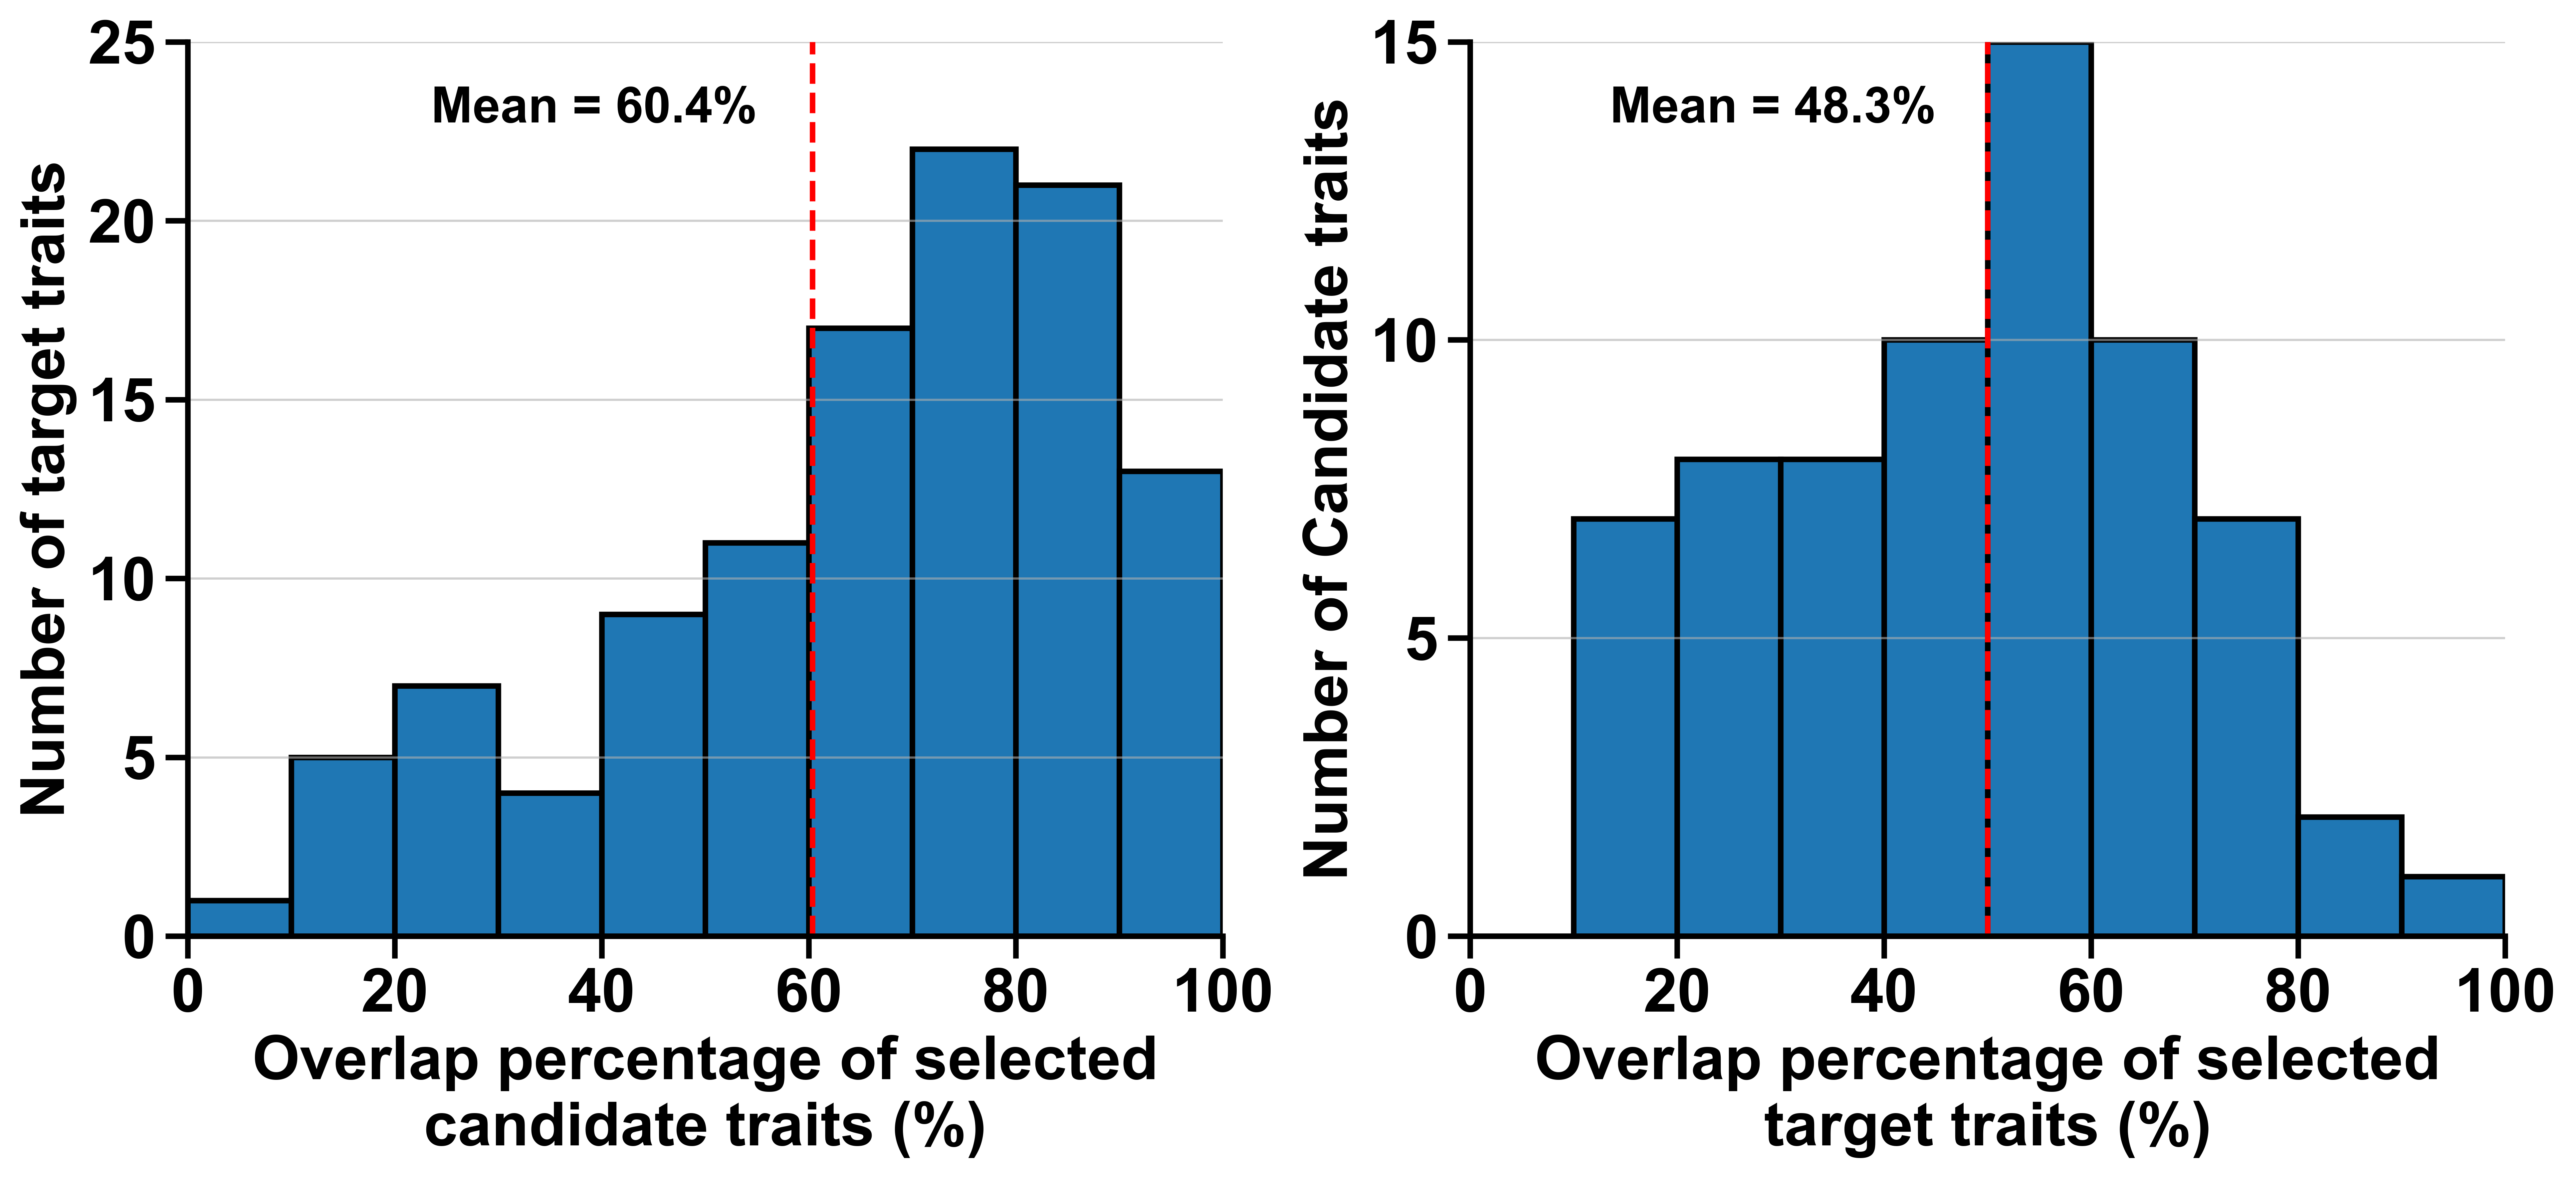

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# ---------- Row overlap count ----------
row_overlap_pct = (aou_bmatrix & ukb_bmatrix).sum(axis=1) / 10 * 100

# ---------- Column overlap percentage ----------
col_intersection = (aou_bmatrix & ukb_bmatrix).sum(axis=0)
col_union = (aou_bmatrix | ukb_bmatrix).sum(axis=0)
mask = col_union > 5
col_overlap_pct = col_intersection[mask] / col_union[mask] * 100

# ---------- Plot ----------
fig, axes = plt.subplots(1, 2, figsize=(13, 6), dpi=600)

# Left: row overlap percentage
axes[0].hist(
    row_overlap_pct,
    bins=np.arange(0, 105, 10),
    edgecolor="black",
    linewidth=2
)

axes[0].axvline(row_overlap_pct.mean(), linestyle="--", linewidth=2, color="red")
axes[0].text(0.55, 0.95, f"Mean = {row_overlap_pct.mean():.1f}%", transform=axes[0].transAxes, ha="right", va="top", fontsize=18, fontweight="bold")
axes[0].set_xlabel("Overlap percentage of selected\ncandidate traits (%)", fontsize=22, fontweight="bold")
axes[0].set_ylabel("Number of target traits", fontsize=22, fontweight="bold")
axes[0].set_ylim(0, 25)

# Right: column overlap percentage
axes[1].hist(
    col_overlap_pct,
    bins=np.arange(0, 105, 10),
    edgecolor="black",
    linewidth=2
)

axes[1].axvline(col_overlap_pct.median(), linestyle="--", linewidth=2, color="red")
axes[1].text(0.45, 0.95, f"Mean = {col_overlap_pct.mean():.1f}%", transform=axes[1].transAxes, ha="right", va="top", fontsize=18, fontweight="bold")
axes[1].set_xlabel("Overlap percentage of selected\ntarget traits (%)", fontsize=22, fontweight="bold")
axes[1].set_ylabel("Number of Candidate traits", fontsize=22, fontweight="bold")
axes[1].set_ylim(0, 15)
axes[1].set_yticks([0, 5, 10, 15])

# Format
for ax in axes:
    ax.set_xlim(0, 100)

    ax.grid(axis="y", alpha=0.6)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(2)
    ax.spines["bottom"].set_linewidth(2)

    ax.tick_params(axis="both", labelsize=22, length=8, width=2)
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontweight("bold")

plt.tight_layout()
plt.show()

### Fig2c. Matrix similarity

In [22]:
# get data
aou_file = os.path.join("../results", "ensemble_prs", "aou_ensembleprs_overall_reporttraits.csv")
aou_data = pd.read_csv(aou_file)

# generate map between phenocode and icd
pheno2icd = pd.read_csv(os.path.join("../reference_data", "european_icd_phenocode_pairs.csv"))

### Construct M-matrix from Top10 selection CSV ###

# Read Top10 selection data
top10_df = pd.read_csv(
    os.path.join(
        "../results",
        "candidate_selection",
        "aou_european_top10_cross_trait_selection.csv"
    )
)

method_list = ["C+T", "LDpred2", "Lassosum2"]

# Make method naming consistent
top10_df["method"] = top10_df["method"].replace({
    "lassosum2": "Lassosum2"
})

# Count number of each method selected in Top10 for each target trait
aou_mmatrix = (
    pd.crosstab(
        top10_df["target_icd"],
        top10_df["method"]
    )
    .reindex(
        index=aou_data["icd"],
        columns=method_list,
        fill_value=0
    )
    .fillna(0)
)

In [24]:
# get data
ukb_file = os.path.join("../results", "ensemble_prs", "ukb_ensembleprs_overall_reporttraits.csv")
ukb_data = pd.read_csv(ukb_file)

# generate map between phenocode and icd
pheno2icd = pd.read_csv(os.path.join("../reference_data", "european_icd_phenocode_pairs.csv"))

### Construct M-matrix from Top10 selection CSV ###

# Read Top10 selection data
top10_df = pd.read_csv(
    os.path.join(
        "../results",
        "candidate_selection",
        "ukb_european_top10_cross_trait_selection.csv"
    )
)

method_list = ["C+T", "LDpred2", "Lassosum2"]

# Make method naming consistent
top10_df["method"] = top10_df["method"].replace({
    "lassosum2": "Lassosum2"
})

# Count number of each method selected in Top10 for each target trait
ukb_mmatrix = (
    pd.crosstab(
        top10_df["target_icd"],
        top10_df["method"]
    )
    .reindex(
        index=ukb_data["icd"],
        columns=method_list,
        fill_value=0
    )
    .fillna(0)
)

In [25]:
# Sort rows and columns by ICD chapter
roman_to_idx = {roman: idx for idx, roman in enumerate(roman_numerals)}

row_meta = pd.DataFrame({"icd": aou_mmatrix.index})
row_meta["chapter"] = row_meta["icd"].apply(assign_chapter)
row_meta["roman"] = row_meta["chapter"].map(chapter2roman_map)
row_meta["roman_index"] = row_meta["roman"].map(roman_to_idx)
row_meta = row_meta.sort_values(["roman_index", "icd"], ascending=[True, True]).reset_index(drop=True)
aou_mmatrix = aou_mmatrix.loc[row_meta["icd"], :]

row_meta = pd.DataFrame({"icd": ukb_mmatrix.index})
row_meta["chapter"] = row_meta["icd"].apply(assign_chapter)
row_meta["roman"] = row_meta["chapter"].map(chapter2roman_map)
row_meta["roman_index"] = row_meta["roman"].map(roman_to_idx)
row_meta = row_meta.sort_values(["roman_index", "icd"], ascending=[True, True]).reset_index(drop=True)
ukb_mmatrix = ukb_mmatrix.loc[row_meta["icd"], :]

In [26]:
# Compute proprotion of selected each method #

# AOU #
# Add chapter annotation
aou_mmatrix["chapter"] = aou_mmatrix.index.map(assign_chapter)
aou_mmatrix["chapter_roman"] = aou_mmatrix["chapter"].map(chapter2roman_map)

# Sum counts within each target chapter
aou_chapter_method_df= (
    aou_mmatrix
    .groupby(["chapter_roman", "chapter"])[method_list]
    .sum()
    .reset_index()
)

# Sort by ICD chapter order
roman_to_idx = {roman: idx for idx, roman in enumerate(roman_numerals)}
aou_chapter_method_df["roman_index"] = aou_chapter_method_df["chapter_roman"].map(roman_to_idx)
aou_chapter_method_df = aou_chapter_method_df.sort_values("roman_index")

# Convert counts to proportions
prop_cols = [f"{m}_prop" for m in method_list]
aou_chapter_method_df[prop_cols] = (
    aou_chapter_method_df[method_list]
    .div(aou_chapter_method_df[method_list].sum(axis=1), axis=0)
)

# UKB #
# Add chapter annotation
ukb_mmatrix["chapter"] = ukb_mmatrix.index.map(assign_chapter)
ukb_mmatrix["chapter_roman"] = ukb_mmatrix["chapter"].map(chapter2roman_map)

# Sum counts within each target chapter
ukb_chapter_method_df= (
    ukb_mmatrix
    .groupby(["chapter_roman", "chapter"])[method_list]
    .sum()
    .reset_index()
)

# Sort by ICD chapter order
roman_to_idx = {roman: idx for idx, roman in enumerate(roman_numerals)}
ukb_chapter_method_df["roman_index"] = ukb_chapter_method_df["chapter_roman"].map(roman_to_idx)
ukb_chapter_method_df = ukb_chapter_method_df.sort_values("roman_index")

# Convert counts to proportions
prop_cols = [f"{m}_prop" for m in method_list]
ukb_chapter_method_df[prop_cols] = (
    ukb_chapter_method_df[method_list]
    .div(ukb_chapter_method_df[method_list].sum(axis=1), axis=0)
)

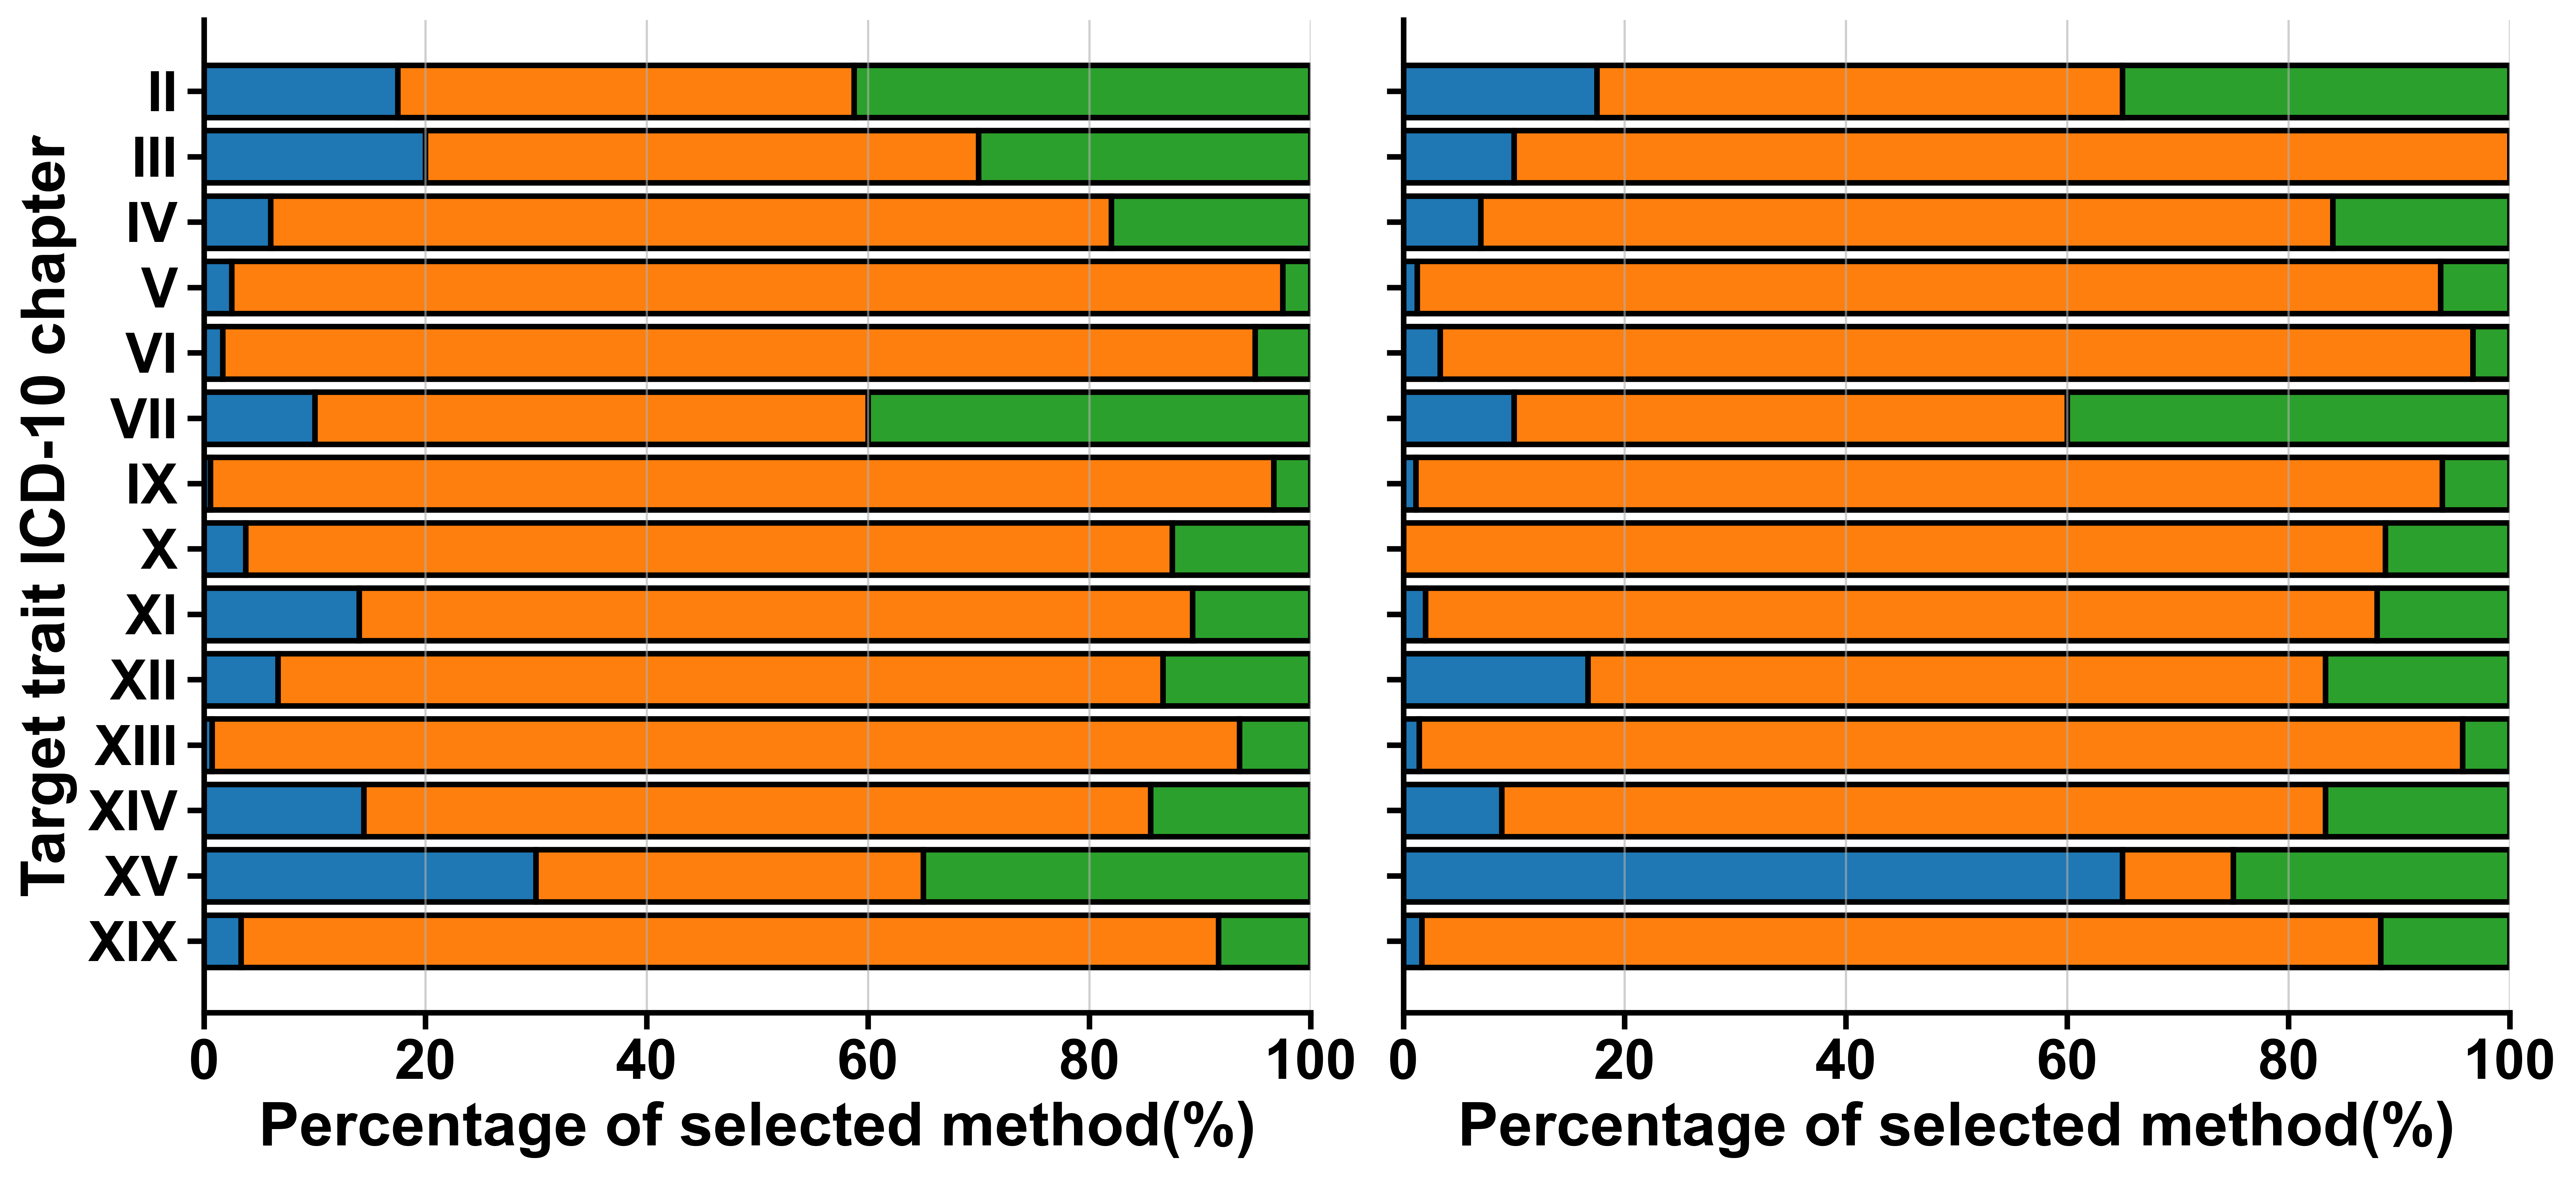

In [27]:
aou_plot = aou_chapter_method_df.iloc[::-1].reset_index(drop=True)
ukb_plot = ukb_chapter_method_df.iloc[::-1].reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 6), sharex=True, sharey=True, dpi=600)

prop_cols = [f"{m}_prop" for m in method_list]

ax = axes[0]

left = np.zeros(len(aou_plot))
for method in prop_cols:
    ax.barh(
        y=np.arange(len(aou_plot)),
        width=aou_plot[method],
        left=left,
        label=method.replace("_prop", ""),
        edgecolor="black",
        linewidth=2,
    )
    left += aou_plot[method].values

ax = axes[1]

left = np.zeros(len(ukb_plot))
for method in prop_cols:
    ax.barh(
        y=np.arange(len(ukb_plot)),
        width=ukb_plot[method],
        left=left,
        label=method.replace("_prop", ""),
        edgecolor="black",
        linewidth=2,
    )
    left += ukb_plot[method].values

# ---------- Format ----------
for i, ax in enumerate(axes):
    ax.set_xlim(0, 1)
    ax.set_xlim(0, 1)
    ax.set_xticks(np.linspace(0, 1, 6))
    ax.set_xticklabels([0, 20, 40, 60, 80, 100], fontsize=20, fontweight="bold")
    ax.set_yticks(np.arange(len(aou_plot)))
    ax.set_yticklabels(aou_plot["chapter_roman"], fontsize=18, fontweight="bold")
    ax.set_xlabel("Percentage of selected method(%)", fontsize=22, fontweight="bold")
    if i == 0:
        ax.set_ylabel("Target trait ICD-10 chapter", fontsize=22, fontweight="bold")

    ax.grid(axis="x", alpha=0.6)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(2)
    ax.spines["bottom"].set_linewidth(2)

    ax.tick_params(axis="both", labelsize=20, width=2, length=6)
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontweight("bold")

plt.tight_layout()
plt.show()

### Fig2d. Hub Traits and Chapters

In [11]:
# hub_score[j] = number of target traits that selected trait j in their Top10
aou_hub_score = (aou_bmatrix.sum(axis=0) / aou_bmatrix.shape[0] * 100).values
ukb_hub_score = (ukb_bmatrix.sum(axis=0) / ukb_bmatrix.shape[0] * 100).values

trait_level_hub = pd.DataFrame({
    "candidate_icd": candidate_trait_list,
    "chapter": [assign_chapter(icd) for icd in candidate_trait_list],
    "aou_hub_score": aou_hub_score,
    "ukb_hub_score": ukb_hub_score
})

chapter_level_hub = (
    trait_level_hub
    .groupby("chapter")
    .agg(
        n_traits=("candidate_icd", "nunique"),
        aou_mean_chapter_hub_score=("aou_hub_score", "mean"),
        ukb_mean_chapter_hub_score=("ukb_hub_score", "mean"),
    )
    .reset_index()
)

# drop chapter less than 5 candidate trait
chapter_level_hub = chapter_level_hub[chapter_level_hub["n_traits"] >= 5]

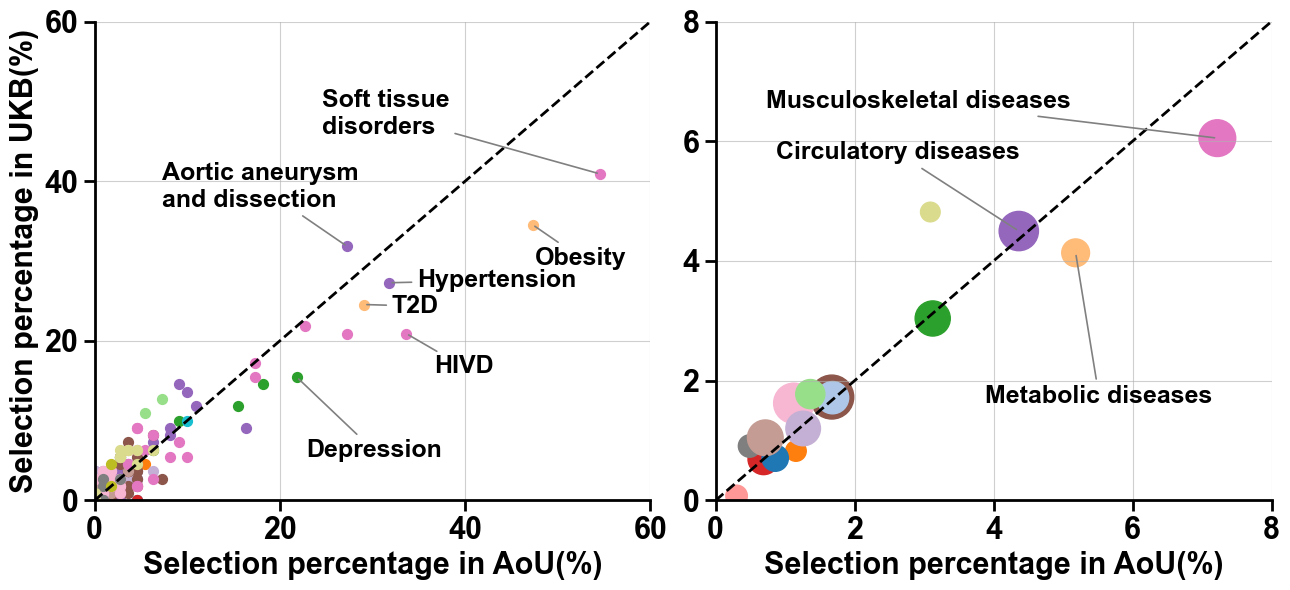

In [12]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import matplotlib

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
matplotlib.rcParams["font.family"] = "Arial"

ax = axes[0]

# Plot all traits, colored by chapter
for chapter in icd_chapters.values():
    mask = trait_level_hub["chapter"] == chapter
    ax.scatter(
        trait_level_hub.loc[mask, "aou_hub_score"],
        trait_level_hub.loc[mask, "ukb_hub_score"],
        color=chapter2color_map[chapter], s=50
    )

# Manually specify ICDs to annotate
icds_to_label = ["E66", "I10", "M51", "I71", "E11", "F32", "M79"]

# Filter to labeled ICDs present in trait_pivot
to_label = trait_level_hub[trait_level_hub["candidate_icd"].isin(icds_to_label)]

# Manual offsets (dx, dy) for each ICD label
manual_offsets = {
    "E66":  (0.3, -5),
    "I10":  (3,   -0.5),
    "M51":  (3,   -5),
    "I71":  (-20,  5),
    "E11":  (3,   -1.0),
    "F32":  (1,   -10),
    "M79":  (-30,  5),
}

# Manually specify disease names for labeled ICDs
icd_to_name = {
    "E66": "Obesity",
    "I10": "Hypertension",
    "M51": "HIVD",
    "I71": "Aortic aneurysm\nand dissection",
    "E11": "T2D",
    "F32": "Depression",
    "M79": "Soft tissue\ndisorders"
}

for _, row in to_label.iterrows():
    dx, dy = manual_offsets.get(row["candidate_icd"], (0.1, 0.1))
    label = icd_to_name.get(row["candidate_icd"], row["candidate_icd"])  # fallback to ICD code if not found
    ax.annotate(
        label,
        xy=(row["aou_hub_score"], row["ukb_hub_score"]),
        xytext=(row["aou_hub_score"] + dx, row["ukb_hub_score"] + dy),
        fontsize=18, fontweight='bold',
        arrowprops=dict(arrowstyle="-", color="gray", lw=1.2),
        annotation_clip=False
    )

ax.plot([0, 60], [0, 60], color="black", linestyle="--", linewidth=2)
ax.set_ylim(0, 60)
ax.set_xlim(0, 60)
ax.set_yticks([0, 20, 40, 60])
ax.set_xticks([0, 20, 40, 60])

ax = axes[1]

ax.scatter(
    chapter_level_hub["aou_mean_chapter_hub_score"], 
    chapter_level_hub["ukb_mean_chapter_hub_score"],
    color=chapter_level_hub["chapter"].map(chapter2color_map), 
    s=chapter_level_hub["n_traits"] * 20
)

# Manually specify ICDs to annotate
icds_to_label = ["Metabolic diseases", "Circulatory diseases", "Musculoskeletal diseases"]

to_label = chapter_level_hub[chapter_level_hub["chapter"].isin(icds_to_label)]

manual_offsets = {
    "Metabolic diseases":       (-1.3, -2.5),
    "Circulatory diseases":     (-3.5,  1.2),
    "Musculoskeletal diseases": (-6.5,  0.5),
}

icd_to_name = {
    "IV":   "IV: Metabolic diseases",
    "IX":   "IX: Circulatory diseases",
    "XIII": "XIII: Musculoskeletal diseases",
}

for _, row in to_label.iterrows():
    dx, dy = manual_offsets.get(row["chapter"], (0.3, 0.3))
    label = icd_to_name.get(row["chapter"], row["chapter"])

    ax.annotate(
        label,
        xy=(row["aou_mean_chapter_hub_score"], row["ukb_mean_chapter_hub_score"]),
        xytext=(row["aou_mean_chapter_hub_score"] + dx, row["ukb_mean_chapter_hub_score"] + dy),
        fontsize=18, fontweight='bold',
        arrowprops=dict(arrowstyle="-", color="gray", lw=1.2),
        annotation_clip=False
    )

ax.plot([0, 8], [0, 8], color="black", linestyle="--", linewidth=2)
ax.set_ylim(0, 8)
ax.set_xlim(0, 8)
ax.set_yticks([0, 2, 4, 6, 8])
ax.set_xticks([0, 2, 4, 6, 8])

for i in range(2):
    ax = axes[i]
    ax.set_xlabel("Selection percentage in AoU(%)", fontsize=22, fontweight="bold")
    if i == 0:
        ax.set_ylabel("Selection percentage in UKB(%)", fontsize=22, fontweight="bold")

    ax.grid(alpha=0.6)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(2)
    ax.spines["bottom"].set_linewidth(2)

    ax.tick_params(axis="both", labelsize=22, length=8, width=2)
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontweight("bold")

plt.tight_layout()
plt.show()

### Fig2e. Within-chapter enrichment

In [13]:
def chapter_enrichment(matrix):
    # matrix: rows = target ICDs, columns = candidate PRS ICDs
    target_trait_chapters = np.array([assign_chapter(icd) for icd in matrix.index])
    candidate_trait_chapters = np.array([assign_chapter(icd) for icd in matrix.columns])

    n_candidate_traits = matrix.shape[1]  # total number of candidate traits

    records = []
    for chap in set(target_trait_chapters):
        row_mask = target_trait_chapters == chap
        col_mask = candidate_trait_chapters == chap

        # DataFrame -> use .iloc
        total_selected = matrix.iloc[row_mask, :].values.sum()
        within_selected = matrix.iloc[row_mask, col_mask].values.sum()

        assert total_selected == row_mask.sum() * 10, (
            f"{chap}: total_selected={total_selected}, expected={row_mask.sum() * 10}"
        )

        p_obs = within_selected / total_selected
        p_exp = col_mask.sum() / n_candidate_traits
        enrichment = p_obs / p_exp 
        log2_enrichment = np.log2(enrichment) 

        records.append({
            "chapter": chap,
            "p_obs": p_obs,
            "p_exp": p_exp,
            "enrichment": enrichment,
            "log2_enrichment": log2_enrichment,
            "n_targets": row_mask.sum(),
            "n_candidates": col_mask.sum(),
            "total_selected": total_selected,
            "within_selected": within_selected,
        })

    return pd.DataFrame(records)

aou_enrich = chapter_enrichment(aou_bmatrix)
ukb_enrich = chapter_enrichment(ukb_bmatrix)

# Merge AoU and UKB into one frame and enforce canonical chapter ordering
merged = aou_enrich.merge(ukb_enrich, on="chapter", suffixes=("_aou", "_ukb"))
merged["chapter_roman"] = merged["chapter"].map(chapter2roman_map)

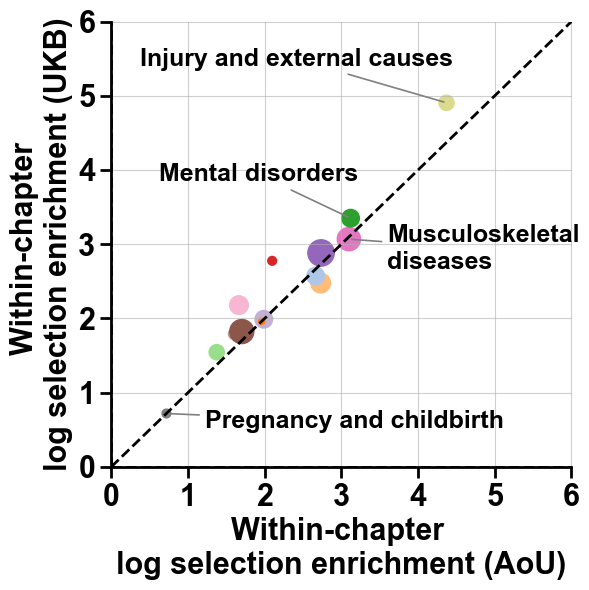

In [14]:
fig, ax = plt.subplots(figsize=(6, 6))
matplotlib.rcParams['font.family'] = 'Arial'

ax.scatter(
    merged["log2_enrichment_aou"],
    merged["log2_enrichment_ukb"],
    color=merged["chapter"].map(chapter2color_map),   
    s=merged["n_targets_aou"] * 20
)

# Manually specify ICDs to annotate
chapters_to_label = [
    "Musculoskeletal diseases",
    "Mental disorders",
    "Injury and external causes",
    "Pregnancy and childbirth"
]

to_label = merged[merged["chapter"].isin(chapters_to_label)].copy()

manual_offsets = {
    "Musculoskeletal diseases":    ( 0.5, -0.4),
    "Mental disorders":            (-2.5,  0.5),
    "Injury and external causes":  (-4.0,  0.5),
    "Pregnancy and childbirth":    ( 0.5, -0.2),
}

chapter_label_map = {
    "Musculoskeletal diseases":   "Musculoskeletal\ndiseases",
    "Mental disorders":           "Mental disorders",
    "Injury and external causes": "Injury and external causes",
    "Pregnancy and childbirth":   "Pregnancy and childbirth",
}

for _, row in to_label.iterrows():
    chapter = row["chapter"]
    dx, dy = manual_offsets.get(chapter, (0.3, 0.3))
    text = ax.annotate(
        chapter_label_map.get(chapter, chapter),
        xy=(row["log2_enrichment_aou"], row["log2_enrichment_ukb"]),
        xytext=(row["log2_enrichment_aou"] + dx, row["log2_enrichment_ukb"] + dy),
        fontsize=18, fontweight='bold',
        arrowprops=dict(arrowstyle="-", color="gray", lw=1.2),
        annotation_clip=False
    )


ax.plot([0, 6], [0, 6], color="black", linestyle="--", linewidth=2)
ax.axvline(0, color="black", linestyle="--", linewidth=2)
ax.axhline(0, color="black", linestyle="--", linewidth=2)
ax.set_ylim(0, 6)
ax.set_xlim(0, 6)
ax.set_yticks([0, 1, 2, 3, 4, 5, 6]); ax.set_xticks([0, 1, 2, 3, 4, 5, 6])
ax.set_xlabel("Within-chapter \nlog selection enrichment (AoU)", fontsize=22, fontweight='bold')
ax.set_ylabel("Within-chapter \nlog selection enrichment (UKB)", fontsize=22, fontweight='bold')

ax.grid(alpha=0.6)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(2)
ax.spines["bottom"].set_linewidth(2)

ax.tick_params(axis="both", labelsize=22, length=8, width=2)
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontweight("bold")

plt.tight_layout()
plt.show()

### Fig2f. Best candidate trait distribution

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib

matplotlib.rcParams["font.family"] = "Arial"

def summarize_best_cross_trait(pmatrix, cohort_name, top_n=5): 
    best_icd = pmatrix.idxmax(axis=1) 
    
    df = pd.DataFrame({"target_icd": pmatrix.index, "best_icd": best_icd.values}) 
    df["is_self_best"] = df["target_icd"] == df["best_icd"] 
    
    n_total = len(df) 
    self_count = df["is_self_best"].sum() 
    self_pct = self_count / n_total * 100 
    other_df = df[~df["is_self_best"]].copy() 
    top_other = ( other_df["best_icd"] .value_counts() .head(top_n) .reset_index() ) 
    top_other.columns = ["category", "count"] 
    top_other["pct"] = top_other["count"] / n_total * 100 
    
    out_df = pd.concat([pd.DataFrame({"category": ["Self PRS"], "count": [self_count], "pct": [self_pct]}), top_other], ignore_index=True) 
    out_df["cohort"] = cohort_name 

    return out_df, df

In [16]:
aou_bar_df, aou_best_detail = summarize_best_cross_trait(aou_pmatrix, cohort_name="AoU", top_n=5)
ukb_bar_df, ukb_best_detail = summarize_best_cross_trait(ukb_pmatrix, cohort_name="UKB", top_n=5)

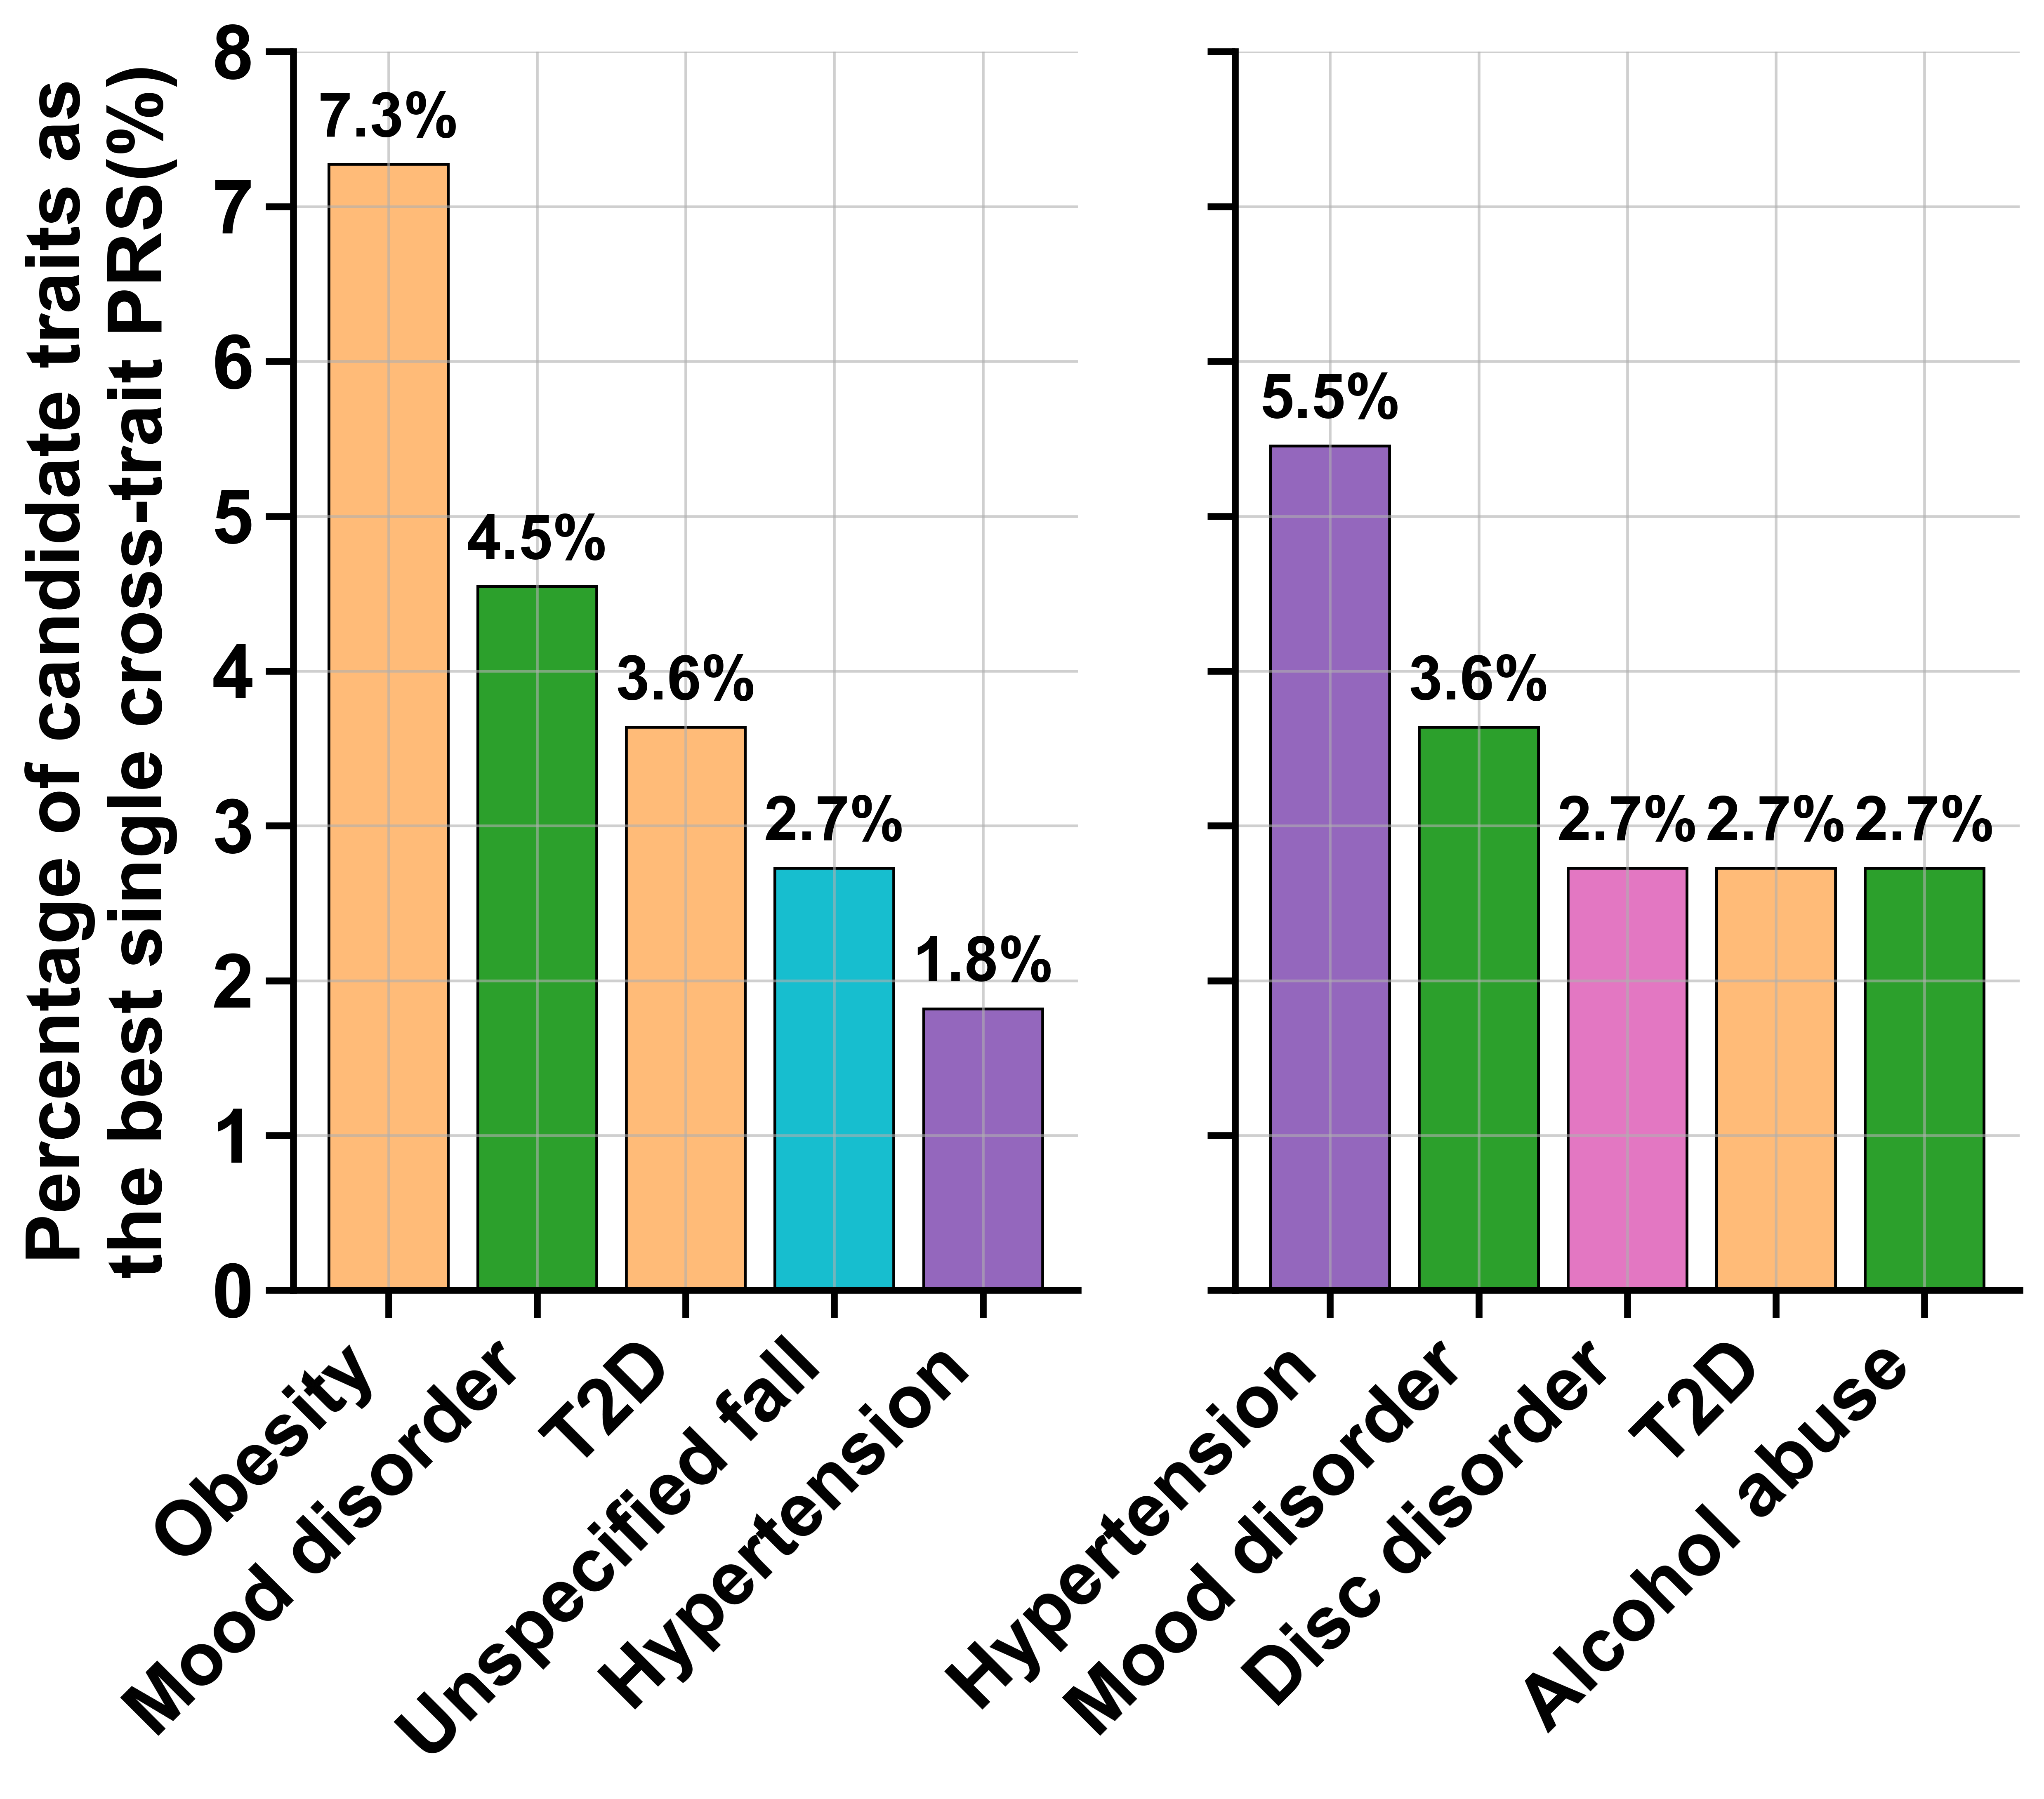

In [17]:
import matplotlib.pyplot as plt 
import matplotlib 

icd_to_name = { "E11": "T2D", 
                "I10": "Hypertension", 
                "M51": "Disc disorder", 
                "F32": "Depression", 
                "E66": "Obesity", 
                "F10": "Alcohol abuse",
                "W19": "Unspecified fall",
                "F39": "Mood disorder"} 

matplotlib.rcParams["font.family"] = "Arial" 

fig, axes = plt.subplots(1, 2, figsize=(9, 6.5), sharey=True, dpi=600)
for ax, bar_df, cohort in zip(axes, [aou_bar_df, ukb_bar_df], ["AoU", "UKB"]): 

    bar_df = bar_df[bar_df["category"] != "Self PRS"].reset_index(drop=True)
    bar_colors = [] 
    labels = [] 
    for cat in bar_df["category"]: 
        if cat == "Self PRS": 
            bar_colors.append("#4C72B0") 
            labels.append("Self PRS") 
            
        else: 
            chapter = assign_chapter(cat) 
            bar_colors.append(chapter2color_map.get(chapter, "lightgray")) 
            disease = icd_to_name.get(cat, "") 
            labels.append(f"{disease}") 
            bars = ax.bar(bar_df["category"], bar_df["pct"], color=bar_colors, edgecolor="black", linewidth=0.8) 
 
    ax.set_xticks(range(len(bar_df))) 
    ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=14, fontweight="bold" ) 
            
    for i, row in bar_df.iterrows(): 
        ax.text(i, row["pct"] + 0.1, f"{row['pct']:.1f}%", ha="center", va="bottom", fontsize=18, fontweight="bold")
        ax.set_ylim(0, 8)
        ax.set_yticks([0, 1, 2, 3, 4, 5, 6, 7, 8])

        ax.grid(alpha=0.6)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.spines["left"].set_linewidth(2)
        ax.spines["bottom"].set_linewidth(2)

        ax.tick_params(axis="both", labelsize=22, length=8, width=2)
        for label in ax.get_xticklabels() + ax.get_yticklabels():
            label.set_fontweight("bold")
        
        axes[0].set_ylabel("Percentage of candidate traits as\nthe best single cross-trait PRS(%)", fontsize=22, fontweight="bold", labelpad=10) 
         
plt.show()